Data Pre-Processing

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
data=pd.read_csv(r'C:\Users\ankur\OneDrive\Desktop\Ecommerce_furniture_dataset.csv')

In [ ]:
# Basic information
data.shape
data.sample(10)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1906 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   productTitle      1906 non-null   object 
 1   originalPrice     1906 non-null   float64
 2   price             1906 non-null   float64
 3   sold              1906 non-null   int64  
 4   tagText           1906 non-null   object 
 5   discount_percent  1906 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 104.2+ KB


In [ ]:
# Check for duplicates and missing values
data.isnull().sum()
data.duplicated().sum()
data[data.duplicated()]
data=data.drop_duplicates()

In [100]:
data[data["tagText"].isnull()]
data["tagText"]=data["tagText"].fillna("Unknown")

In [ ]:
# Removing '$' and ',' from columns and converting to float
data["price"]=(
    data["price"].astype(str)
    .str.replace(",","", regex=False)
    .str.replace("$","", regex=False)
    .str.strip()
)
data["originalPrice"]=(
    data["originalPrice"].astype(str)
    .str.replace(",","", regex=False)
    .str.replace("$","", regex=False)
    .str.strip()
)
data.sample(10)

data.dtypes
d_change=["originalPrice","price"]
for i in d_change:
    data[i]=data[i].astype(float)
data.dtypes



productTitle      object
originalPrice    float64
price            float64
sold               int64
tagText           object
dtype: object

In [102]:
data.isnull().sum()
data["originalPrice"]=data["originalPrice"].fillna(data["price"])
data.sample(20)
data.isnull().sum()



productTitle     0
originalPrice    0
price            0
sold             0
tagText          0
dtype: int64

In [ ]:
# Outlier detection in 'price' using IQR method
Q1 = data["price"].quantile(0.25)
Q3 = data["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = data[(data["price"] < lower) | (data["price"] > upper)]
price_outliers.shape
price_outliers.head(126)



,productTitle,originalPrice,price,sold,tagText
7,"Living Room Furniture, Modern 3-Piece Includin...",1474.17,734.58,5,Free shipping
12,3/4/5 Piece Boho Outdoor Patio Furniture Sets ...,495.80,495.80,0,Free shipping
14,Modern luxury lounge chair home furniture hote...,978.88,978.88,0,Free shipping
15,Furniture Contemporary Reversible Sectional Sl...,440.94,440.94,0,Free shipping
25,6Pieces Wicker Patio Furniture Sets Outdoor Co...,574.86,574.86,0,Free shipping
...,...,...,...,...,...
1942,Dellbeck Casual Rectangular Dining Extension T...,459.60,459.60,1,Free shipping
1960,"7 Pieces Outdoor Patio Furniture, Durable Wick...",448.79,448.79,1,Free shipping
1971,"Garden Furniture Sets, Outdoor PE Rattan Loung...",456.80,456.80,0,Free shipping
1974,"Garden Furniture 7 Pieces Set, Patio Furniture...",432.76,432.76,1,Free shipping


In [104]:
data.to_csv(r'C:\Users\ankur\OneDrive\Desktop\Ecommerce_furniture_cleaned_dataset.csv', index=False)

Exploratory Data Analysis

In [108]:
data[["price","originalPrice"]].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
price,1906.0,154.360152,176.969831,0.99,47.4650,112.48,191.5425,2876.38
originalPrice,1906.0,186.709706,259.773508,1.01,56.7625,120.64,207.2625,3265.13


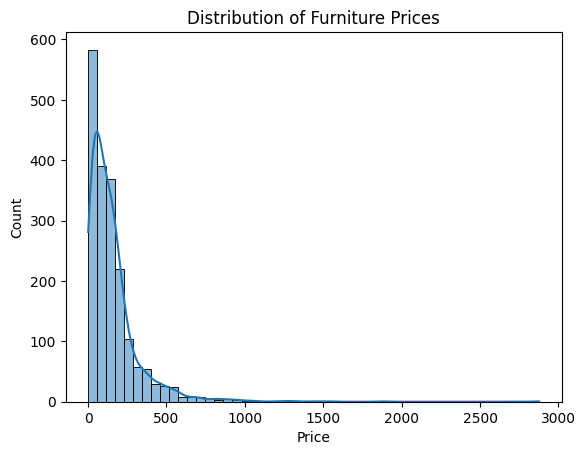

In [110]:
sns.histplot(data["price"], bins=50, kde=True)
plt.title("Distribution of Furniture Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [ ]:
# Calculate discount percentage
data["discount_percent"] = (
    (data["originalPrice"] - data["price"]) / data["originalPrice"]
) * 100

data["discount_percent"].describe()

count    1906.000000
mean       11.588848
std        22.261507
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        91.458154
Name: discount_percent, dtype: float64

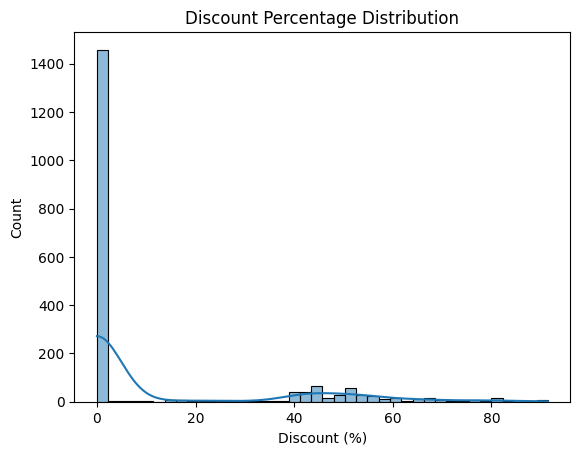

In [116]:
sns.histplot(data["discount_percent"], bins=40, kde=True)
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount (%)")
plt.show()


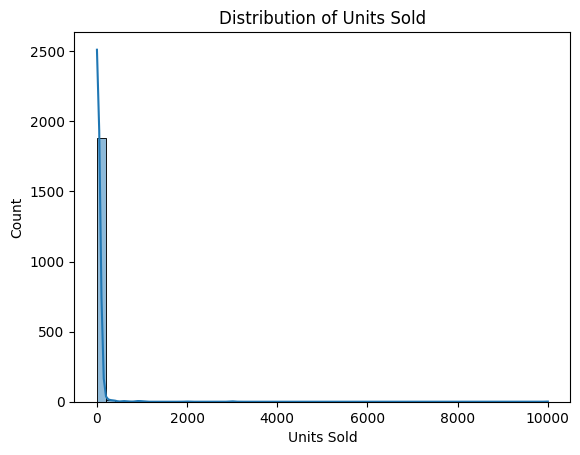

In [120]:
data["sold"].describe()

sns.histplot(data["sold"], bins=50, kde=True)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Count")
plt.show()



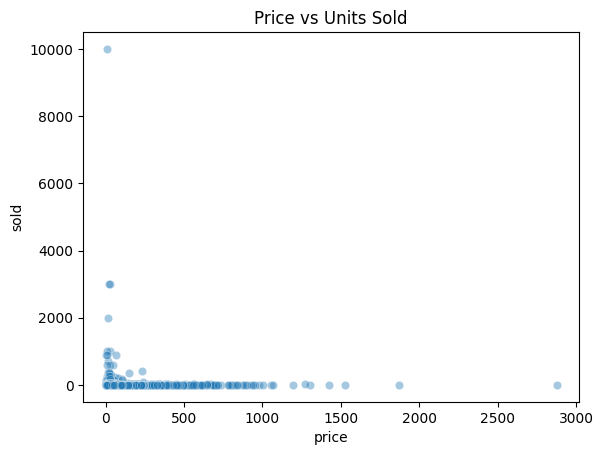

In [124]:
sns.scatterplot(x="price", y="sold", data=data, alpha=0.4)
plt.title("Price vs Units Sold")
plt.show()


In [125]:
data.groupby("tagText")["sold"].mean().sort_values(ascending=False)
data.groupby("tagText")["price"].median().sort_values(ascending=False)

tagText
+Shipping: $109.18    233.46
+Shipping: $381.73    217.95
+Shipping: $97.54     167.02
+Shipping: $110.64    155.24
+Shipping: $171.49    144.44
                       ...  
+Shipping: $14.97       3.94
+Shipping: $21.65       3.62
+Shipping: $7.38        3.38
+Shipping: $8.86        3.13
+Shipping: $14.91       2.84
Name: price, Length: 101, dtype: float64

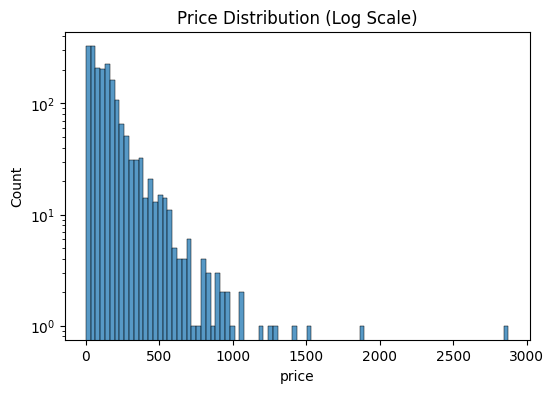

In [126]:
plt.figure(figsize=(6,4))
sns.histplot(data["price"])
plt.yscale("log")
plt.title("Price Distribution (Log Scale)")
plt.show()
